In [4]:
import os
import numpy as np
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm


In [5]:
OUTPUT_DIR = "../../Outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

MODEL_NAMES = {
    0: "Real",
    1: "SD2.1",
    2: "SDXL",
    3: "SD3",
    4: "DALL·E 3",
    5: "Midjourney"
}

MODEL_COLORS = {
    0: "#2ecc71",       # green  — real
    1: "#3498db",       # blue
    2: "#9b59b6",       # purple
    3: "#e67e22",       # orange
    4: "#e74c3c",       # red
    5: "#1abc9c"        # teal
}

In [6]:
# Load dataset
ds = load_dataset("Rajarshi-Roy-research/Defactify_Image_Dataset", split="train[:1000]")

df = pd.DataFrame({
    "Label_A": ds["Label_A"],
    "Label_B": ds["Label_B"],
    "Caption": ds["Caption"]
})
df["Model"] = df["Label_B"].map(MODEL_NAMES)

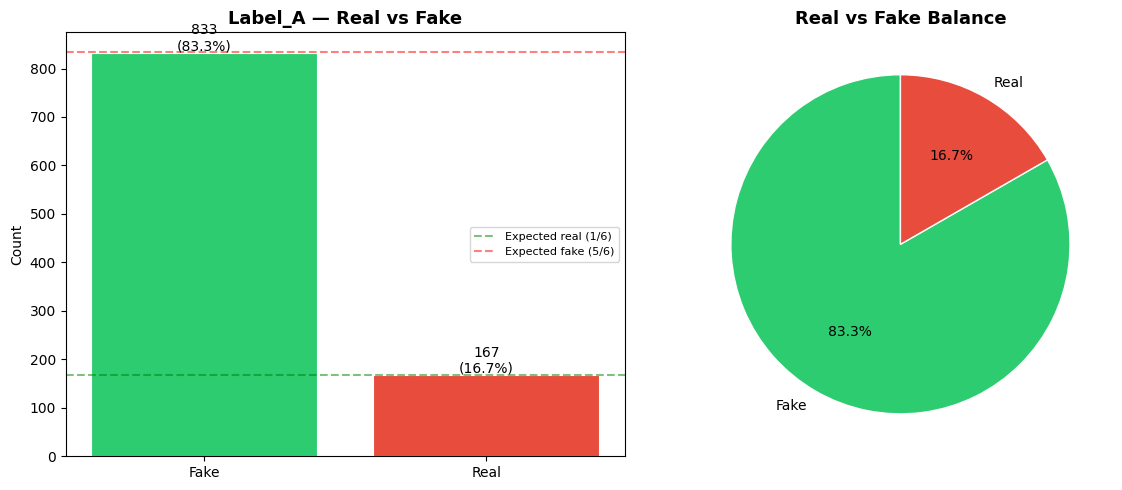

In [7]:
# PLOT 1 — Label_A: Real vs Fake distribution

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

label_a_counts = df["Label_A"].map({0: "Real", 1: "Fake"}).value_counts()
axes[0].bar(label_a_counts.index, label_a_counts.values,
            color=["#2ecc71", "#e74c3c"], edgecolor="white", linewidth=0.8)
axes[0].set_title("Label_A — Real vs Fake", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Count")
for i, v in enumerate(label_a_counts.values):
    axes[0].text(i, v + 5, f"{v}\n({v/len(df)*100:.1f}%)", ha="center", fontsize=10)

# Expected ratio line
axes[0].axhline(len(df) / 6, color="green", linestyle="--", alpha=0.5, label="Expected real (1/6)")
axes[0].axhline(len(df) * 5 / 6, color="red", linestyle="--", alpha=0.5, label="Expected fake (5/6)")
axes[0].legend(fontsize=8)

# Pie
axes[1].pie(label_a_counts.values, labels=label_a_counts.index,
            colors=["#2ecc71", "#e74c3c"], autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Real vs Fake Balance", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_label_a_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

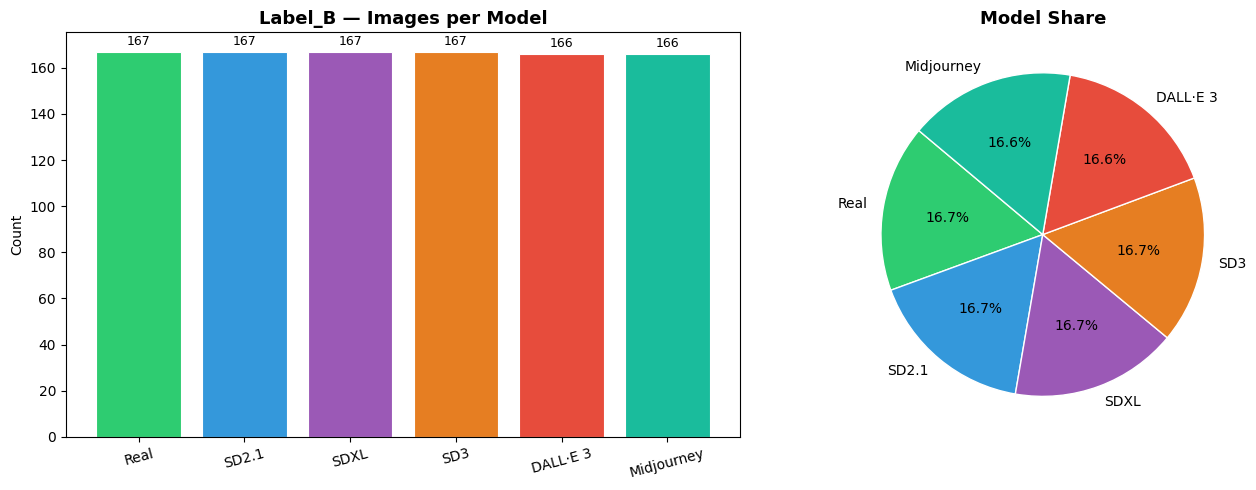

In [8]:
#PLOT 2 — Label_B: Per-model distribution

model_counts = df["Model"].value_counts().reindex(MODEL_NAMES.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(model_counts.index, model_counts.values,
                   color=[MODEL_COLORS[k] for k in MODEL_NAMES.keys()],
                   edgecolor="white", linewidth=0.8)
axes[0].set_title("Label_B — Images per Model", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=15)
for bar, v in zip(bars, model_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                 str(v), ha="center", fontsize=9)

axes[1].pie(model_counts.values, labels=model_counts.index,
            colors=[MODEL_COLORS[k] for k in MODEL_NAMES.keys()],
            autopct="%1.1f%%", startangle=140,
            wedgeprops={"edgecolor": "white"})
axes[1].set_title("Model Share", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/02_label_b_model_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

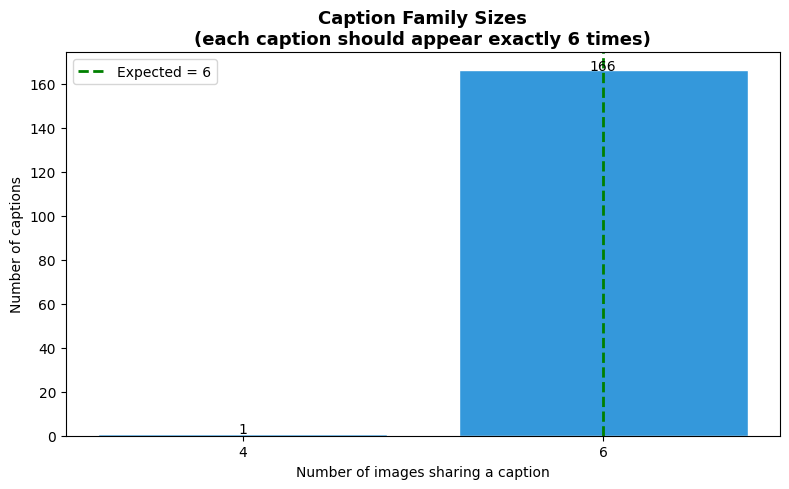

In [9]:
# PLOT 3 — Caption family verification (should all be 6)

caption_counts = df["Caption"].value_counts()
family_sizes = caption_counts.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(family_sizes.index.astype(str), family_sizes.values,
       color="#3498db", edgecolor="white")
ax.set_title("Caption Family Sizes\n(each caption should appear exactly 6 times)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Number of images sharing a caption")
ax.set_ylabel("Number of captions")
ax.axvline(x="6", color="green", linestyle="--", linewidth=2, label="Expected = 6")
ax.legend()
for i, v in enumerate(family_sizes.values):
    ax.text(i, v + 0.3, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/03_caption_family_sizes.png", dpi=150, bbox_inches="tight")
plt.show()

Scanning dimensions: 100%|██████████| 1000/1000 [00:04<00:00, 246.84it/s]


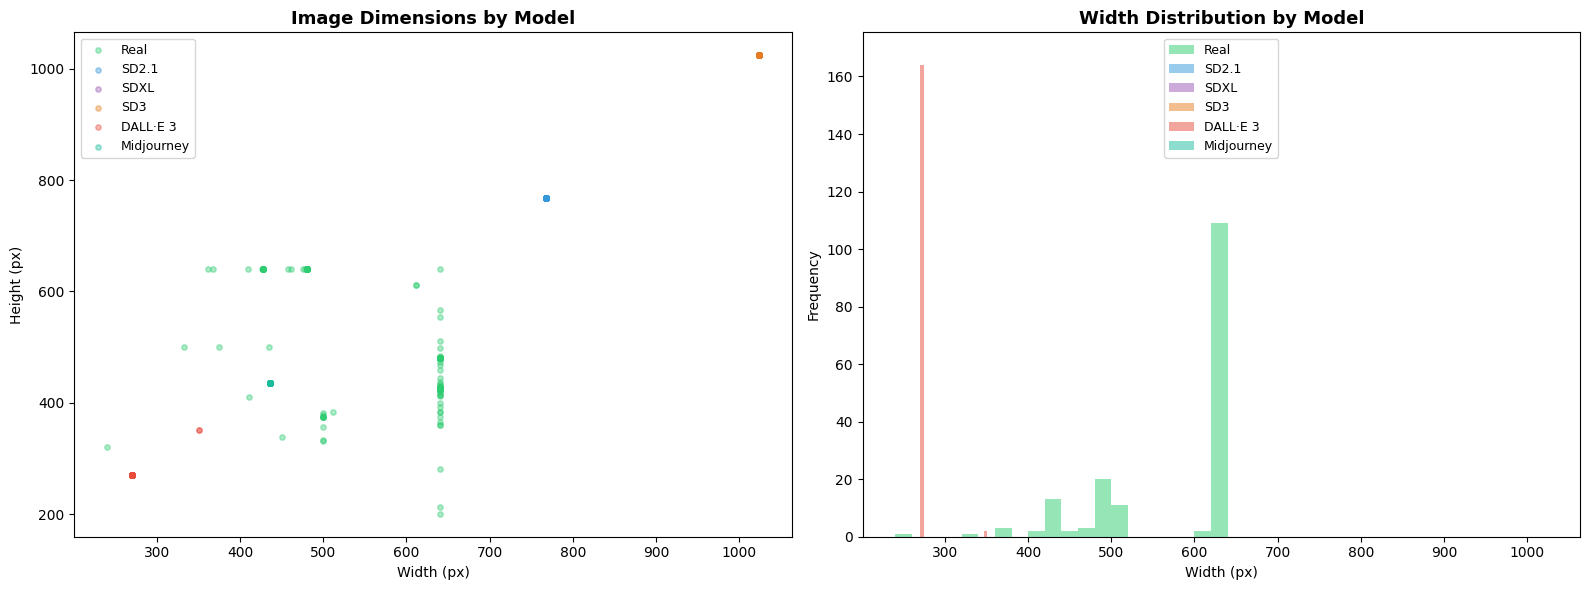

In [10]:
# PLOT 4 — Image dimensions: Real vs Fake scatter

dim_data = {k: {"widths": [], "heights": []} for k in MODEL_NAMES.keys()}

for ex in tqdm(ds, desc="Scanning dimensions"):
    img = ex["Image"]
    if not isinstance(img, Image.Image):
        img = Image.fromarray(img)
    lb = ex["Label_B"]
    dim_data[lb]["widths"].append(img.width)
    dim_data[lb]["heights"].append(img.height)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for lb, data in dim_data.items():
    axes[0].scatter(data["widths"], data["heights"],
                    alpha=0.4, s=15,
                    color=MODEL_COLORS[lb],
                    label=MODEL_NAMES[lb])

axes[0].set_title("Image Dimensions by Model", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Height (px)")
axes[0].legend(fontsize=9)

for lb, data in dim_data.items():
    axes[1].hist(data["widths"], bins=20, alpha=0.5,
                 color=MODEL_COLORS[lb], label=MODEL_NAMES[lb])

axes[1].set_title("Width Distribution by Model", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Width (px)")
axes[1].set_ylabel("Frequency")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_image_dimensions.png", dpi=150, bbox_inches="tight")
plt.show()

Computing pixel stats: 100%|██████████| 1000/1000 [00:21<00:00, 45.54it/s]


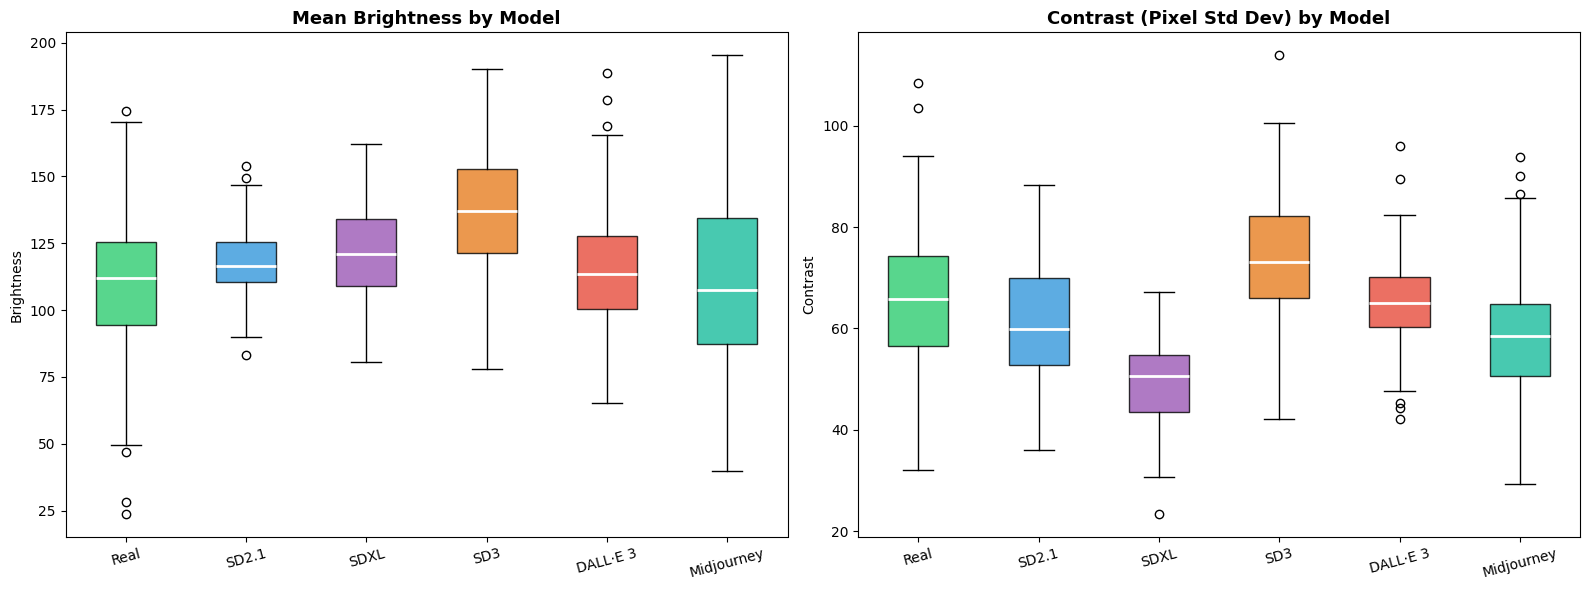

In [11]:
# PLOT 5 — Per-model brightness & contrast stats

stats = {k: {"brightness": [], "contrast": []} for k in MODEL_NAMES.keys()}

for ex in tqdm(ds, desc="Computing pixel stats"):
    img = ex["Image"]
    if not isinstance(img, Image.Image):
        img = Image.fromarray(img)
    arr = np.array(img.convert("RGB")).astype(float)
    lb = ex["Label_B"]
    stats[lb]["brightness"].append(arr.mean())
    stats[lb]["contrast"].append(arr.std())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for metric, ax, title in zip(
    ["brightness", "contrast"],
    axes,
    ["Mean Brightness by Model", "Contrast (Pixel Std Dev) by Model"]
):
    data_to_plot = [stats[k][metric] for k in MODEL_NAMES.keys()]
    bp = ax.boxplot(data_to_plot, patch_artist=True, notch=False,
                    medianprops={"color": "white", "linewidth": 2})
    for patch, lb in zip(bp["boxes"], MODEL_NAMES.keys()):
        patch.set_facecolor(MODEL_COLORS[lb])
        patch.set_alpha(0.8)
    ax.set_xticklabels(MODEL_NAMES.values(), rotation=15, fontsize=10)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel(metric.capitalize())

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/05_brightness_contrast.png", dpi=150, bbox_inches="tight")
plt.show()

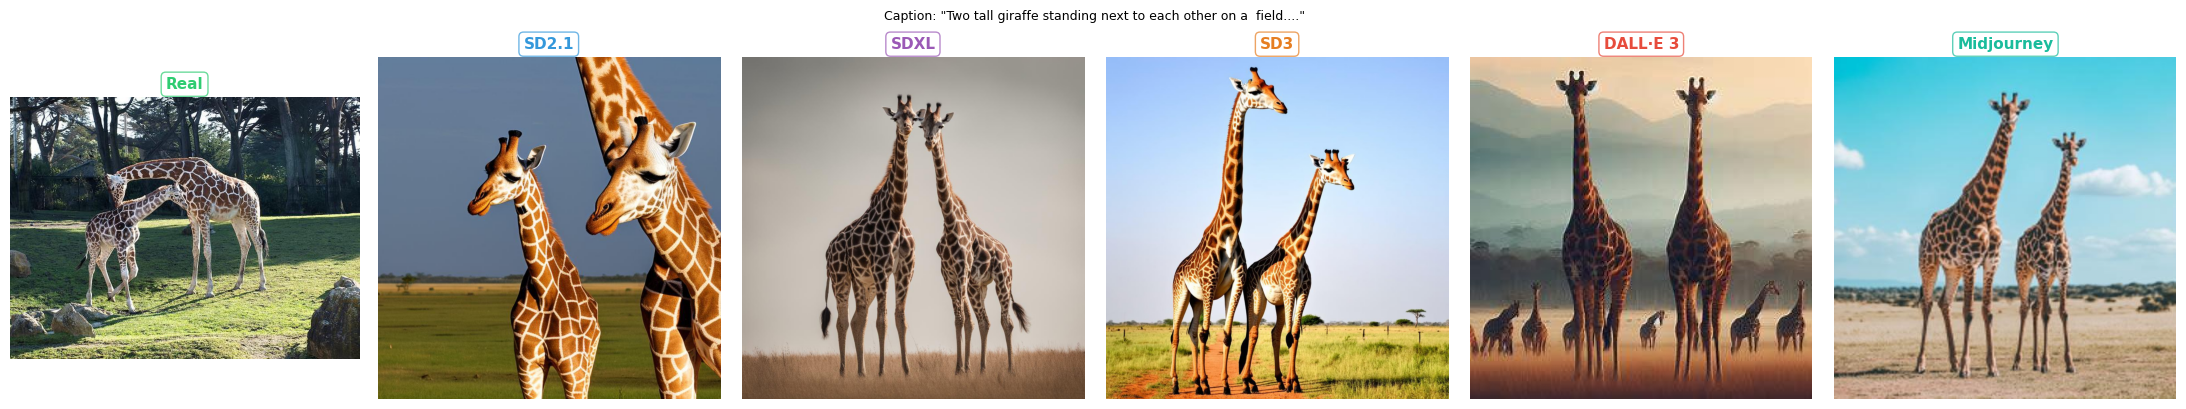

In [12]:
# PLOT 6 — Family comparison: 1 real + 5 AI models side by side

complete_captions = caption_counts[caption_counts == 6].index
sample_caption = complete_captions[0]
family = [ex for ex in ds if ex["Caption"] == sample_caption]
family_sorted = sorted(family, key=lambda x: x["Label_B"])

fig, axes = plt.subplots(1, 6, figsize=(22, 4))
for ax, ex in zip(axes, family_sorted):
    img = ex["Image"]
    if not isinstance(img, Image.Image):
        img = Image.fromarray(img)
    lb = ex["Label_B"]
    name = MODEL_NAMES[lb]
    ax.imshow(img)
    ax.set_title(name, fontsize=11, fontweight="bold",
                 color=MODEL_COLORS[lb],
                 bbox=dict(facecolor="white", alpha=0.7, edgecolor=MODEL_COLORS[lb], boxstyle="round"))
    ax.axis("off")

plt.suptitle(f'Caption: "{sample_caption[:90]}..."', fontsize=9, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/06_family_comparison.png", dpi=150, bbox_inches="tight")
plt.show()